In [1]:
# 07_ML_kmeans
# Celda 1: Setup y carga de la Super Tabla

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Montar Drive si no está montado
from google.colab import drive
drive.mount('/content/drive')

# Ruta al proyecto
RUTA_PROCESSED = '/content/drive/MyDrive/Proyecto_ZMM/data_processed/'

# Cargar super tabla
df = pd.read_csv(RUTA_PROCESSED + 'super_tabla_completa.csv', parse_dates=['fecha_hora'])

print(f"Shape: {df.shape}")
print(f"Rango temporal: {df['fecha_hora'].min()} → {df['fecha_hora'].max()}")
print(f"\nColumnas ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nNulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "Cero nulos")

Mounted at /content/drive
Shape: (35064, 29)
Rango temporal: 2023-01-01 00:00:00 → 2026-12-31 23:00:00

Columnas (29):
['fecha_hora', 'año', 'mes', 'dia_semana', 'hora_del_dia', 'es_fin_de_semana', 'intensidad_hora_pico', 'tipo_dia', 'asistencia_estimada', 'nivel_impacto', 'impacto_evento_activo', 'temperatura_c', 'nivel_lluvia', 'siniestros_zona_industrial', 'Total de lesionados', 'Total de fallecidos', 'tiene_coordenadas', 'sin_apodaca', 'sin_guadalupe', 'sin_escobedo', 'sin_garcia', 'sin_juarez', 'sin_pesqueria', 'sin_santa_catarina', 'sin_san_nicolas', 'dist_industrial_promedio', 'dist_industrial_minima', 'siniestros_en_zona', 'masa_laboral_max']

Nulos por columna:
dist_industrial_promedio    14017
dist_industrial_minima      14017
siniestros_en_zona          14017
masa_laboral_max            14017
dtype: int64


In [2]:
# Celda 2: Filtro temporal y selección de features

# Filtrar a datos reales: 2023-01-01 → 2025-12-31
df_real = df[(df['fecha_hora'] >= '2023-01-01') &
             (df['fecha_hora'] <= '2025-12-31 23:00:00')].copy()

print(f"Shape original: {df.shape}")
print(f"Shape filtrado: {df_real.shape}")
print(f"Filas eliminadas (futuro sin datos): {df.shape[0] - df_real.shape[0]}")
print(f"Rango temporal real: {df_real['fecha_hora'].min()} → {df_real['fecha_hora'].max()}")

# Features para clustering de horas (sin las espaciales con NaN)
features_clustering = [
    'hora_del_dia',
    'dia_semana',
    'es_fin_de_semana',
    'intensidad_hora_pico',
    'temperatura_c',
    'nivel_lluvia',
    'impacto_evento_activo',
    'asistencia_estimada',
    'siniestros_zona_industrial',
    'Total de lesionados',
    'Total de fallecidos'
]

X = df_real[features_clustering].copy()

print(f"\n--- Features seleccionadas ({len(features_clustering)}) ---")
print(X.dtypes)
print(f"\nNulos en X: {X.isnull().sum().sum()}")
print(f"\nEstadísticas descriptivas (antes de escalar):")
print(X.describe().round(2))

Shape original: (35064, 29)
Shape filtrado: (26304, 29)
Filas eliminadas (futuro sin datos): 8760
Rango temporal real: 2023-01-01 00:00:00 → 2025-12-31 23:00:00

--- Features seleccionadas (11) ---
hora_del_dia                    int64
dia_semana                      int64
es_fin_de_semana                int64
intensidad_hora_pico            int64
temperatura_c                 float64
nivel_lluvia                    int64
impacto_evento_activo         float64
asistencia_estimada           float64
siniestros_zona_industrial      int64
Total de lesionados             int64
Total de fallecidos             int64
dtype: object

Nulos en X: 0

Estadísticas descriptivas (antes de escalar):
       hora_del_dia  dia_semana  es_fin_de_semana  intensidad_hora_pico  \
count      26304.00     26304.0          26304.00              26304.00   
mean          11.50         3.0              0.29                  0.58   
std            6.92         2.0              0.45                  0.81   
min     

--- Verificación del escalado ---
Medias después de escalar (deben ser ~0):
hora_del_dia                 -0.0
dia_semana                   -0.0
es_fin_de_semana             -0.0
intensidad_hora_pico         -0.0
temperatura_c                 0.0
nivel_lluvia                  0.0
impacto_evento_activo        -0.0
asistencia_estimada          -0.0
siniestros_zona_industrial    0.0
Total de lesionados           0.0
Total de fallecidos           0.0
dtype: float64

Desviaciones estándar después de escalar (deben ser ~1):
hora_del_dia                  1.0
dia_semana                    1.0
es_fin_de_semana              1.0
intensidad_hora_pico          1.0
temperatura_c                 1.0
nivel_lluvia                  1.0
impacto_evento_activo         1.0
asistencia_estimada           1.0
siniestros_zona_industrial    1.0
Total de lesionados           1.0
Total de fallecidos           1.0
dtype: float64


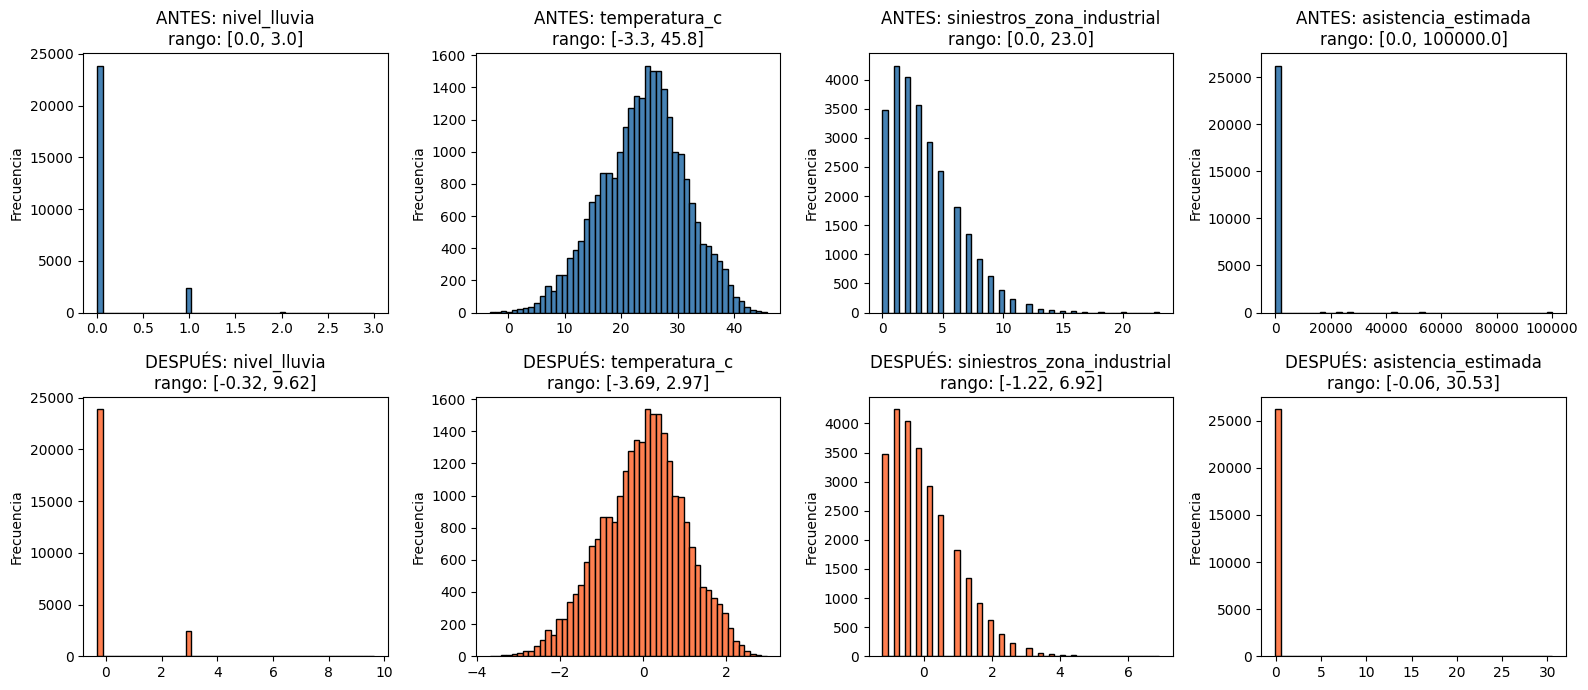


✓ Escalado completado. X_scaled listo para K-Means.


In [3]:
# Celda 3: StandardScaler con visualización antes/después

from sklearn.preprocessing import StandardScaler

# Aplicar StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir de vuelta a DataFrame para inspección
X_scaled_df = pd.DataFrame(X_scaled, columns=features_clustering, index=X.index)

# Verificación: media debe ser ~0, std debe ser ~1
print("--- Verificación del escalado ---")
print(f"Medias después de escalar (deben ser ~0):")
print(X_scaled_df.mean().round(4))
print(f"\nDesviaciones estándar después de escalar (deben ser ~1):")
print(X_scaled_df.std().round(4))

# Visualización: comparar 4 variables antes y después
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
vars_a_visualizar = ['nivel_lluvia', 'temperatura_c', 'siniestros_zona_industrial', 'asistencia_estimada']

for i, var in enumerate(vars_a_visualizar):
    # Antes (arriba)
    axes[0, i].hist(X[var], bins=50, color='steelblue', edgecolor='black')
    axes[0, i].set_title(f'ANTES: {var}\nrango: [{X[var].min():.1f}, {X[var].max():.1f}]')
    axes[0, i].set_ylabel('Frecuencia')

    # Después (abajo)
    axes[1, i].hist(X_scaled_df[var], bins=50, color='coral', edgecolor='black')
    axes[1, i].set_title(f'DESPUÉS: {var}\nrango: [{X_scaled_df[var].min():.2f}, {X_scaled_df[var].max():.2f}]')
    axes[1, i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Proyecto_ZMM/data_processed/nb07_escalado_antes_despues.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Escalado completado. X_scaled listo para K-Means.")

Probando valores de K...

K=2: inercia=245885 | silhouette=0.2519 | tiempo=1.3s
K=3: inercia=217476 | silhouette=0.2461 | tiempo=1.1s
K=4: inercia=189944 | silhouette=0.2056 | tiempo=1.1s
K=5: inercia=170670 | silhouette=0.2293 | tiempo=1.0s
K=6: inercia=153936 | silhouette=0.2341 | tiempo=0.8s
K=7: inercia=141685 | silhouette=0.2299 | tiempo=0.9s
K=8: inercia=126780 | silhouette=0.2426 | tiempo=0.9s


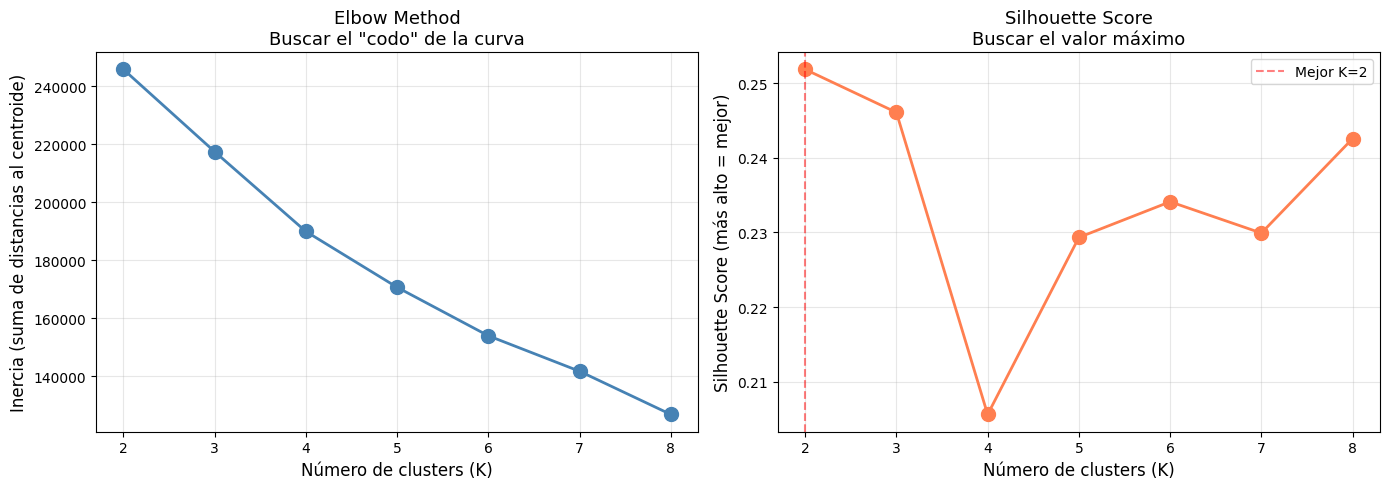


--- Resumen ---
Mejor K según Silhouette: 2 (score = 0.2519)
Tiempo total: 7.2s


In [4]:
# Celda 4: Encontrar K óptimo con Elbow Method + Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

# Rango de K a probar
k_range = range(2, 9)

inercias = []
silhouettes = []
tiempos = []

print("Probando valores de K...\n")
for k in k_range:
    inicio = time.time()

    # Entrenar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Calcular métricas
    inercia = kmeans.inertia_
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)

    inercias.append(inercia)
    silhouettes.append(sil)

    tiempo = time.time() - inicio
    tiempos.append(tiempo)

    print(f"K={k}: inercia={inercia:.0f} | silhouette={sil:.4f} | tiempo={tiempo:.1f}s")

# Visualizar resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inercias, 'o-', color='steelblue', linewidth=2, markersize=10)
axes[0].set_xlabel('Número de clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia (suma de distancias al centroide)', fontsize=12)
axes[0].set_title('Elbow Method\nBuscar el "codo" de la curva', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, 'o-', color='coral', linewidth=2, markersize=10)
axes[1].set_xlabel('Número de clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score (más alto = mejor)', fontsize=12)
axes[1].set_title('Silhouette Score\nBuscar el valor máximo', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Marcar el K con mejor silhouette
mejor_k_sil = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(x=mejor_k_sil, color='red', linestyle='--', alpha=0.5, label=f'Mejor K={mejor_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Proyecto_ZMM/data_processed/nb07_eleccion_k.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n--- Resumen ---")
print(f"Mejor K según Silhouette: {mejor_k_sil} (score = {max(silhouettes):.4f})")
print(f"Tiempo total: {sum(tiempos):.1f}s")

--- Distribución de horas por cluster ---
Cluster 0:    352 horas ( 1.34%)
Cluster 1:   2412 horas ( 9.17%)
Cluster 2:  10065 horas (38.26%)
Cluster 3:   6913 horas (26.28%)
Cluster 4:   6562 horas (24.95%)

--- Perfil de cada cluster (media de features) ---
cluster_hora                       0      1      2      3      4
hora_del_dia                   17.74  11.65  15.53   5.45  11.31
dia_semana                      4.22   3.07   2.01   1.96   5.51
es_fin_de_semana                0.63   0.30   0.00   0.00   1.00
intensidad_hora_pico            1.16   0.66   0.90   0.09   0.55
temperatura_c                  27.08  22.80  27.01  19.67  23.95
nivel_lluvia                    0.13   1.02   0.00   0.00   0.00
impacto_evento_activo           2.58   0.00   0.01   0.00   0.00
asistencia_estimada         13960.51   7.05   1.59   0.00   0.00
siniestros_zona_industrial      4.49   3.66   5.14   1.41   2.85
Total de lesionados             0.66   0.39   0.57   0.18   0.46
Total de fallecidos       

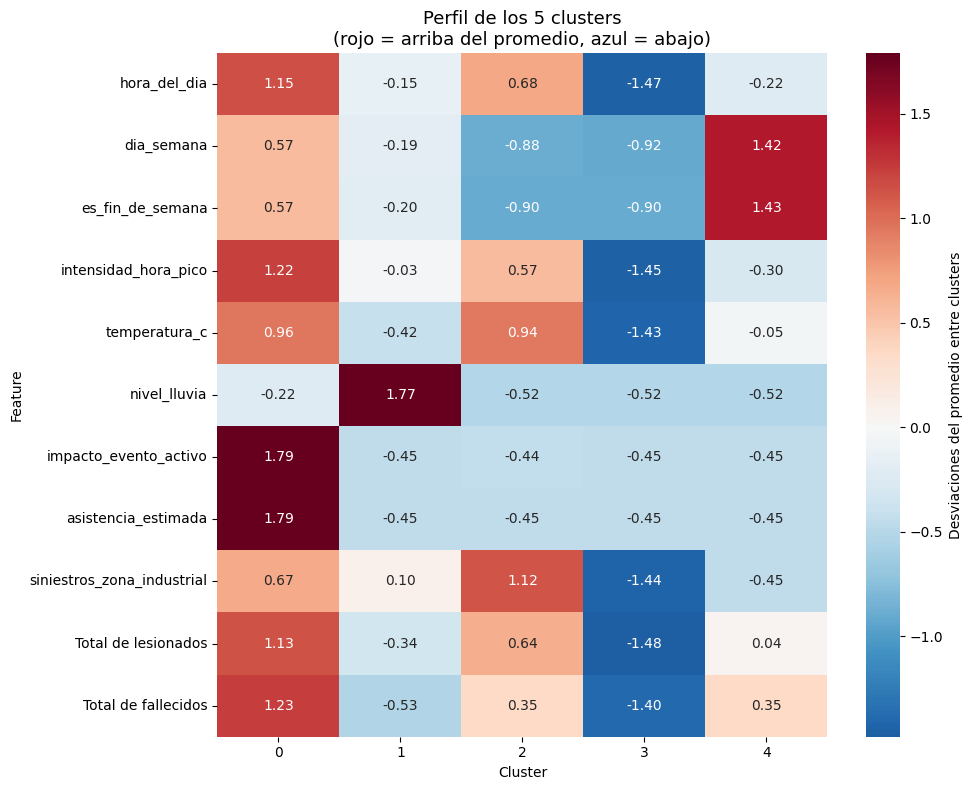


✓ Modelo entrenado. Columna 'cluster_hora' agregada al dataframe.


In [5]:
# Celda 5: Entrenar K-Means final con K=5 y caracterizar perfiles

# Entrenar modelo final
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_real['cluster_hora'] = kmeans_final.fit_predict(X_scaled)

# Distribución de horas por cluster
print("--- Distribución de horas por cluster ---")
distribucion = df_real['cluster_hora'].value_counts().sort_index()
for cluster_id, count in distribucion.items():
    pct = (count / len(df_real)) * 100
    print(f"Cluster {cluster_id}: {count:>6} horas ({pct:5.2f}%)")

# Caracterización: media de cada feature por cluster
print("\n--- Perfil de cada cluster (media de features) ---")
perfil_clusters = df_real.groupby('cluster_hora')[features_clustering].mean().round(2)
print(perfil_clusters.T)  # Transpuesto para que sea más legible

# Heatmap de los perfiles (visualización rápida)
fig, ax = plt.subplots(figsize=(10, 8))

# Normalizar perfiles para visualización (z-score por feature, para comparar entre clusters)
perfil_normalizado = (perfil_clusters - perfil_clusters.mean()) / perfil_clusters.std()

sns.heatmap(perfil_normalizado.T,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Desviaciones del promedio entre clusters'},
            ax=ax)
ax.set_title('Perfil de los 5 clusters\n(rojo = arriba del promedio, azul = abajo)', fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Proyecto_ZMM/data_processed/nb07_perfiles_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Modelo entrenado. Columna 'cluster_hora' agregada al dataframe.")

In [6]:
# Celda final NB07 - Persistir cluster_hora al CSV

# Verificar que df_real tiene la columna cluster_hora
assert 'cluster_hora' in df_real.columns, "Falta cluster_hora en df_real"
print(f"Shape df_real: {df_real.shape}")
print(f"Distribución de clusters:")
print(df_real['cluster_hora'].value_counts().sort_index())

# Guardar como nuevo CSV (NO sobrescribir el original)
ruta_salida = '/content/drive/MyDrive/Proyecto_ZMM/data_processed/super_tabla_con_clusters.csv'
df_real.to_csv(ruta_salida, index=False)

# Verificar guardado
df_check = pd.read_csv(ruta_salida)
print(f"\n✓ Archivo guardado en: {ruta_salida}")
print(f"Shape verificado: {df_check.shape}")
print(f"Columna cluster_hora presente: {'cluster_hora' in df_check.columns}")
print(f"\nPrimeras 3 filas con cluster_hora:")
print(df_check[['fecha_hora', 'hora_del_dia', 'siniestros_zona_industrial', 'cluster_hora']].head(3))

Shape df_real: (26304, 30)
Distribución de clusters:
cluster_hora
0      352
1     2412
2    10065
3     6913
4     6562
Name: count, dtype: int64

✓ Archivo guardado en: /content/drive/MyDrive/Proyecto_ZMM/data_processed/super_tabla_con_clusters.csv
Shape verificado: (26304, 30)
Columna cluster_hora presente: True

Primeras 3 filas con cluster_hora:
            fecha_hora  hora_del_dia  siniestros_zona_industrial  cluster_hora
0  2023-01-01 00:00:00             0                           1             4
1  2023-01-01 01:00:00             1                           3             4
2  2023-01-01 02:00:00             2                           2             4
